The project follows this pipeline:

Image/Video → Preprocessing → Model → Training → Evaluation → Prediction → Deployment

### Why transfer learning? 

Check how many images are there in each class?

In [ ]:
import os

from pathlib import Path
from PIL import Image
from collections import Counter
import hashlib
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [81]:
DATA_DIR = Path("Project_Dataset/train")  # Folder where data will be stored
TEST_DIR = Path("Project_Dataset/test")

IMG_SIZE = 224      # Good default for ResNet
BATCH_SIZE = 32
EPOCHS = 10          
VAL_RATIO = 0.2     # Split trainval into train/val


## EDA & Data Cleaning

### Count images per class

In [82]:
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        num_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{class_name}: {num_images}")

cricket_ball: 581
basketball: 340
baseball: 400
bowling_ball: 440
tennis_ball: 490
hockey_ball: 530
hockey_puck: 390
shuttlecock: 429
volleyball: 432
billiard_ball: 646
rugby_ball: 493
football: 604
golf_ball: 549
american_football: 384
table_tennis_ball: 620


### Check image dimensions

In [83]:
for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        dimensions = []

        for img_path in folder.iterdir():
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    with Image.open(img_path) as img:
                        dimensions.append(img.size)
                except:
                    pass

        print(f"\n{folder.name}")
        print(Counter(dimensions).most_common(10))


cricket_ball
[((225, 225), 123), ((500, 500), 15), ((1000, 1000), 14), ((300, 300), 12), ((800, 800), 11), ((600, 600), 10), ((275, 183), 8), ((400, 400), 7), ((354, 354), 7), ((320, 320), 7)]

basketball
[((225, 225), 43), ((800, 800), 11), ((275, 183), 10), ((612, 612), 7), ((1000, 1000), 6), ((500, 500), 6), ((187, 270), 5), ((1200, 800), 5), ((1000, 1500), 4), ((1280, 720), 4)]

baseball
[((225, 225), 66), ((300, 168), 12), ((275, 183), 10), ((800, 800), 7), ((1024, 1024), 6), ((259, 194), 5), ((600, 600), 5), ((1280, 720), 5), ((612, 612), 5), ((1000, 1000), 5)]

bowling_ball
[((225, 225), 49), ((275, 183), 21), ((1280, 720), 18), ((259, 194), 15), ((300, 168), 9), ((1000, 1080), 5), ((1200, 630), 5), ((500, 500), 5), ((1280, 1280), 4), ((225, 224), 4)]

tennis_ball
[((225, 225), 90), ((275, 183), 17), ((1000, 1000), 10), ((600, 600), 10), ((300, 168), 8), ((800, 800), 8), ((1280, 720), 8), ((700, 700), 8), ((224, 224), 7), ((1200, 1200), 5)]

hockey_ball
[((225, 225), 107), ((60

### Find corrupted images

In [84]:
corrupted = []

for img_path in DATA_DIR.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)

print("Corrupted images:", len(corrupted))

for img in corrupted:
    print(img)

Corrupted images: 0


### Find duplicate images

In [85]:
hashes = defaultdict(list)

for img_path in DATA_DIR.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

        with open(img_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        hashes[file_hash].append(img_path)

duplicates = {
    h: files
    for h, files in hashes.items()
    if len(files) > 1
}

for h, files in duplicates.items():
    print("\nDuplicate:")
    for file in files:
        print(file)


Duplicate:
Project_Dataset/train/rugby_ball/rugby_ball_135.jpg
Project_Dataset/train/american_football/american_football_561.jpg


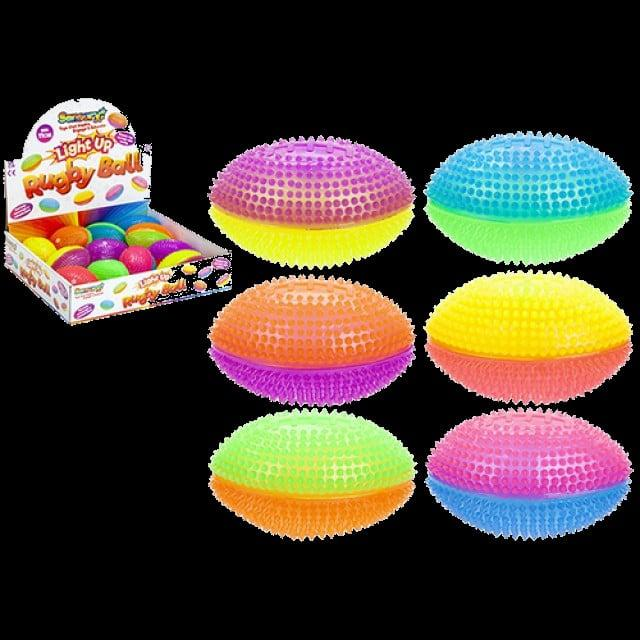

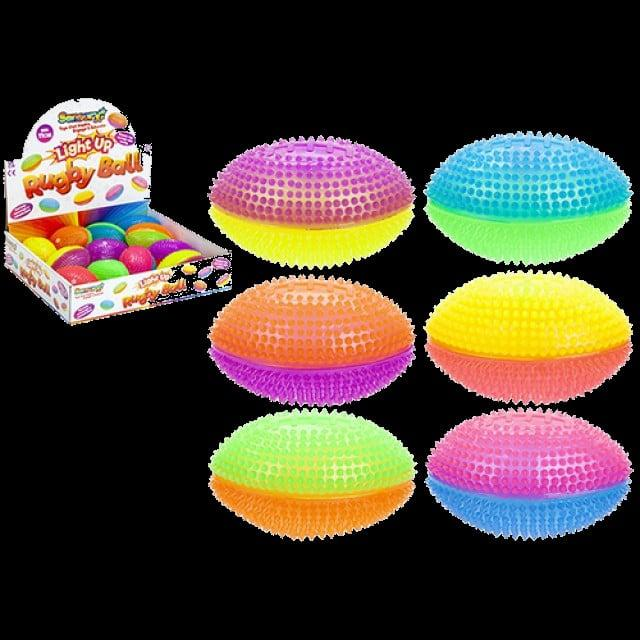

In [86]:
img1_path = "Project_Dataset/train/rugby_ball/rugby_ball_135.jpg"
img2_path = "Project_Dataset/train/american_football/american_football_561.jpg"

img1 = Image.open(img1_path)
img2 = Image.open(img2_path)

display(img1)
display(img2)

In [87]:
# remove the ambiguous image
os.remove(img1_path)
os.remove(img2_path)

**Reason for removal:**

The image is ambiguous and cannot be reliably classified as either American football or rugby.
Keeping it could introduce label noise and cause the model to learn misleading features such as text or color.

### Visual inspection

we look for things like:

1. Wrongly labeled images
2. Images that belong to another class
3. Corrupted/unreadable images
4. Very unusual images
5. Images where the ball is barely visible
6. Images containing multiple different balls
7. Images with text/watermarks that might give the model the answer
8. background: "Is the background strongly associated with a particular class?"

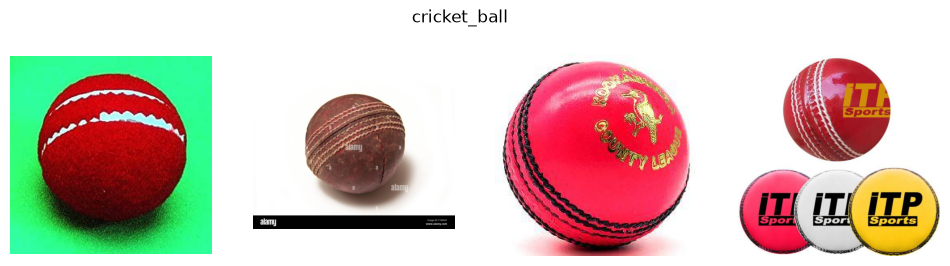

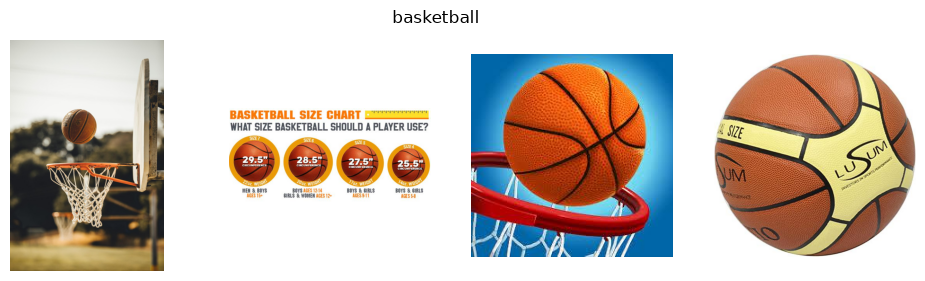

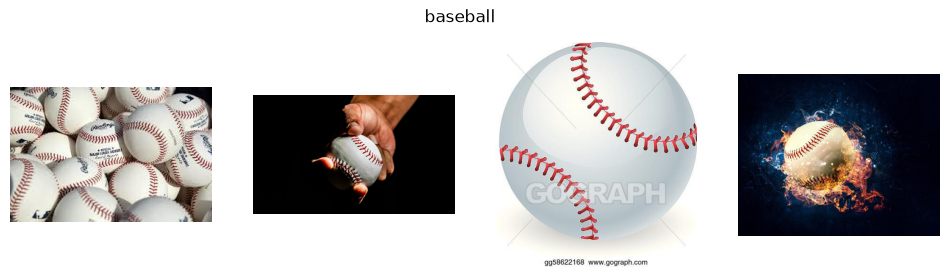

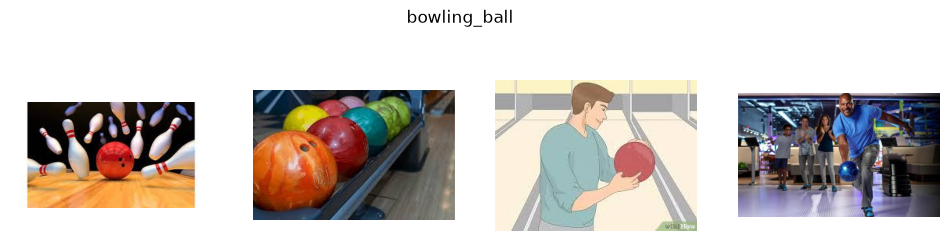

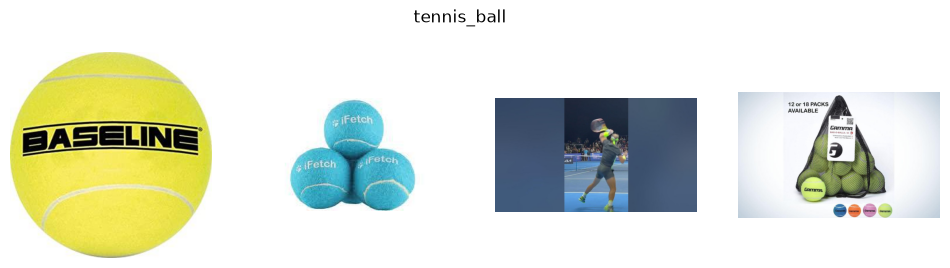

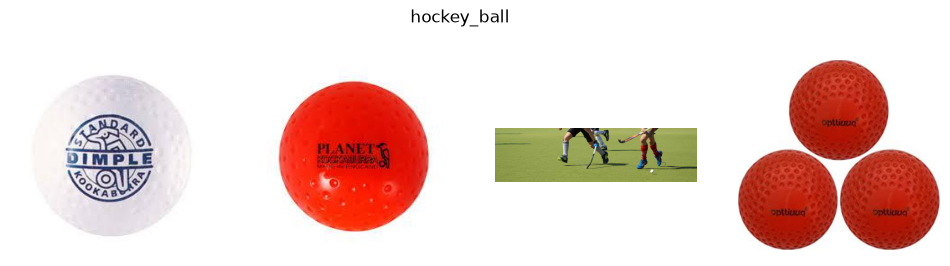

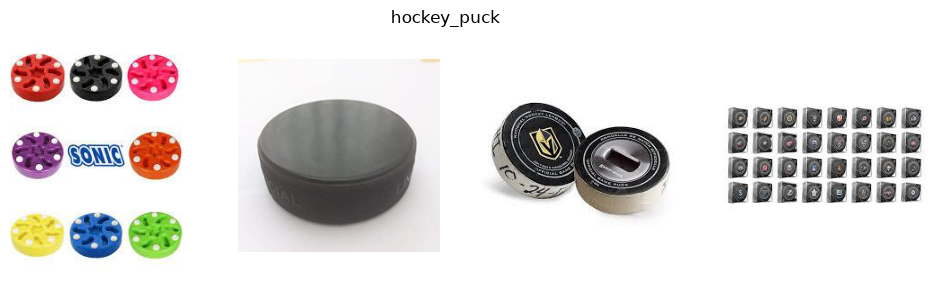

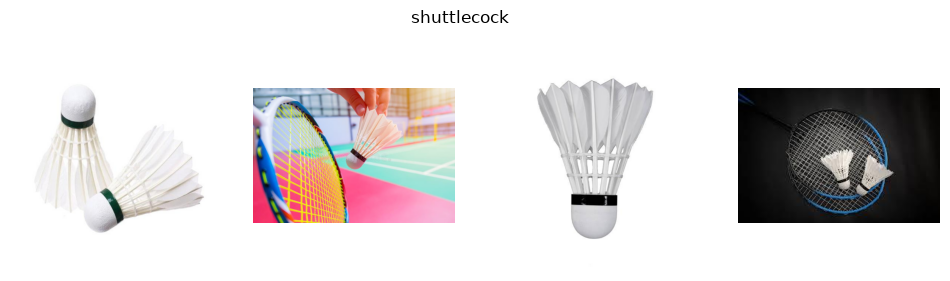

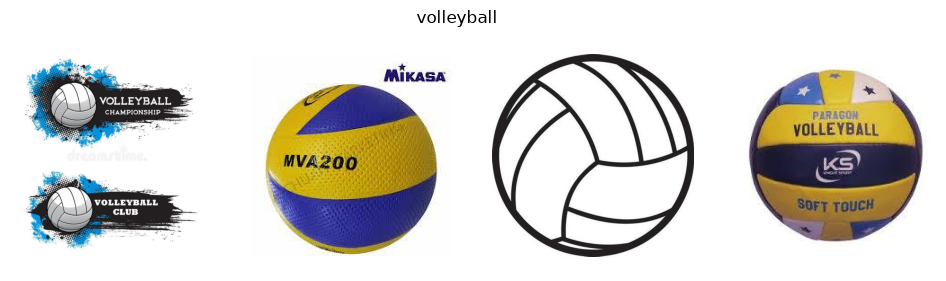

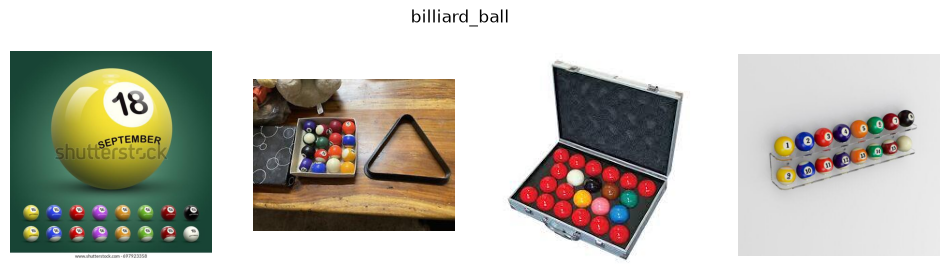

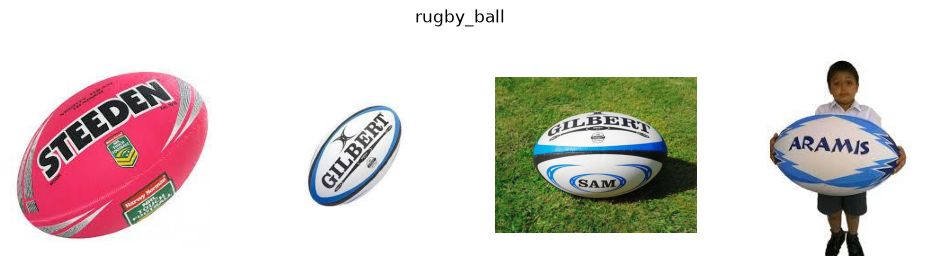

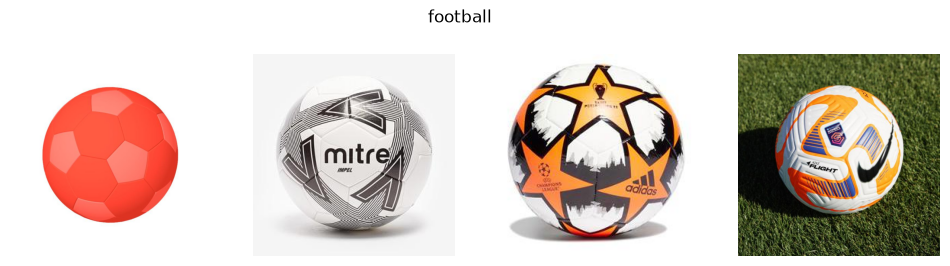

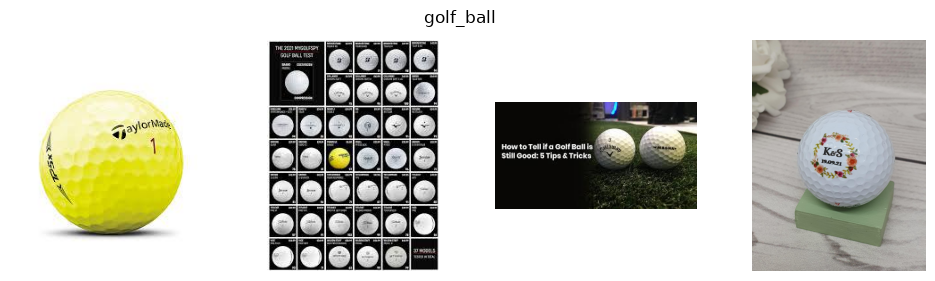

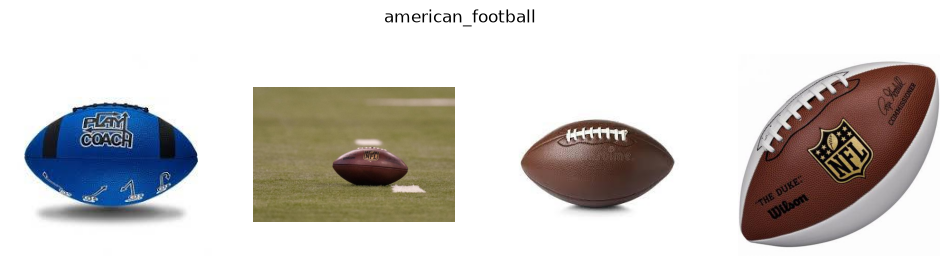

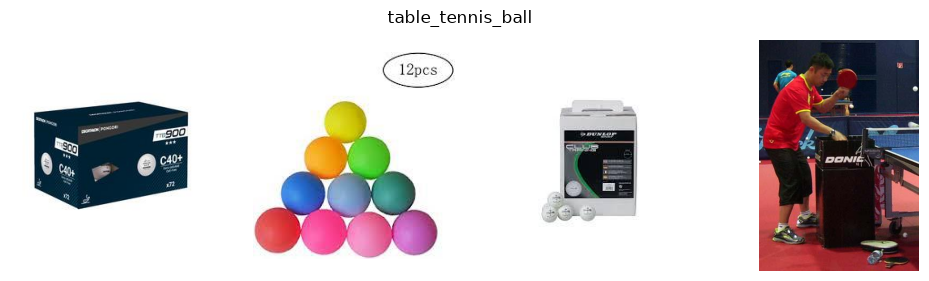

In [ ]:
classes = os.listdir(DATA_DIR)

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    selected_images = random.sample(images, min(4, len(images)))

    plt.figure(figsize=(12, 3))
    plt.suptitle(class_name)

    for i, image_name in enumerate(selected_images):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)

        plt.subplot(1, 4, i + 1)
        plt.imshow(image)
        plt.axis("off")

    plt.show()

In [89]:
selected_images

['table_tennis_ball_128.jpg',
 'table_tennis_ball_428.jpg',
 'table_tennis_ball_106.jpg',
 'table_tennis_ball_933.jpg']

### Check lighting

In [ ]:
for img_path in DATA_DIR.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

        img = cv2.imread(str(img_path))

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = np.mean(gray)

        print(img_path, brightness)

Project_Dataset/train/cricket_ball/cricket_ball_1014.jpg 177.438049417914
Project_Dataset/train/cricket_ball/cricket_ball_594.jpg 78.68405505333628
Project_Dataset/train/cricket_ball/cricket_ball_706.jpg 239.29046913580248
Project_Dataset/train/cricket_ball/cricket_ball_23.jpg 113.92825520527687
Project_Dataset/train/cricket_ball/cricket_ball_87.jpg 81.09802048726468
Project_Dataset/train/cricket_ball/cricket_ball_464.jpg 179.61724444444445
Project_Dataset/train/cricket_ball/cricket_ball_104.jpg 172.12785869565218
Project_Dataset/train/cricket_ball/cricket_ball_778.jpg 70.56689153439153
Project_Dataset/train/cricket_ball/cricket_ball_740.jpg 208.77924872585416
Project_Dataset/train/cricket_ball/cricket_ball_1075.jpg 204.18710304858686
Project_Dataset/train/cricket_ball/cricket_ball_343.jpg 119.27020089285715
Project_Dataset/train/cricket_ball/cricket_ball_291.jpg 142.30536041666667
Project_Dataset/train/cricket_ball/cricket_ball_1068.jpg 166.356375
Project_Dataset/train/cricket_ball/cr

unusual images
backgrounds
lighting
different viewpoints
images where the ball is very small
images containing multiple balls

## Preprocessing 

### transformers

In [ ]:
# ImageNet normalization (ResNet was trained this way)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Training: resize, augment, normalize
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(1.0, 1.0)),  # scale: the crop keeps 80–100% of the original area
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Validation/Test: only resize + normalize, no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

### Load the train/test dataset

In [ ]:
print(os.getcwd())
print(os.listdir())

/home/sanam/Desktop/ai_daneshkar_bootcamp/7_CV/assignment/cv_project
['cv_project.ipynb', 'Project_Dataset', 'cv_venv', 'Project_Dataset.zip', 'project (1).pdf']


In [95]:
full_train_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

full_val_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform
)

In [96]:
num_classes = len(full_train_dataset.classes)  # should be 15
print("Number of classes:", num_classes)

Number of classes: 15


### Train / Validation Split

In [97]:
# ============================================
# 5. Train/Validation split
# ============================================
full_size = len(full_train_dataset)
val_size = int(VAL_RATIO * full_size)
train_size = full_size - val_size

train_dataset, val_indices = random_split(
    range(full_size),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = torch.utils.data.Subset(
    full_train_dataset,
    train_dataset
)

val_dataset = torch.utils.data.Subset(
    full_val_dataset,
    val_indices
)

train → augmentation ✅

validation → no augmentation ✅

test → no augmentation ✅

### DataLoaders

In [98]:
# ============================================
#  DataLoaders
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## Load Pretrain

In [ ]:
# ============================================
#  Load pretrained ResNet18 and modify head
# ============================================

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)
# Freeze all layers (backbone)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last ResNet block
for param in model.layer4.parameters():
    param.requires_grad = True
    
# Replace the final fully connected layer:
# Original: model.fc = Linear(512 -> 1000)
# We want: 512 -> num_classes (15)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

# Print model summary-ish info
print(model)
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {num_trainable:,} / {num_total:,}")


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Loss and optimizer

In [100]:
# ============================================
#  Loss function & optimizer
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.fc.parameters(),   # only train classifier head
    lr=1e-4
)

## Training

In [ ]:
# ============================================
#  Training loop (simple: train loss + val loss)
# ============================================
train_accuracy = []
val_accuracy = []
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # ----- Training -----
    model.train()
    running_train_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)           # shape: [batch, num_classes]
        loss = criterion(outputs, labels) # CrossEntropyLoss

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_accuracy = correct / total

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_accuracy = val_correct / val_total
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    # Save history
    train_accuracy.append(epoch_train_accuracy)
    val_accuracy.append(epoch_val_accuracy)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}"
          f"Train Acc: {train_accuracy:.4f} | "
          f"Val Acc: {val_accuracy:.4f}")

print("Training finished ✅")

Epoch [1/10] - Train Loss: 2.5646 | Val Loss: 2.3109Train Acc: 0.1848 | Val Acc: 0.3072
Epoch [2/10] - Train Loss: 2.1409 | Val Loss: 1.9505Train Acc: 0.4178 | Val Acc: 0.4901
Epoch [3/10] - Train Loss: 1.8435 | Val Loss: 1.6929Train Acc: 0.5376 | Val Acc: 0.5980
Epoch [4/10] - Train Loss: 1.6412 | Val Loss: 1.5125Train Acc: 0.6004 | Val Acc: 0.6341
Epoch [5/10] - Train Loss: 1.5024 | Val Loss: 1.3923Train Acc: 0.6245 | Val Acc: 0.6614
Epoch [6/10] - Train Loss: 1.3776 | Val Loss: 1.2851Train Acc: 0.6586 | Val Acc: 0.6853
Epoch [7/10] - Train Loss: 1.3005 | Val Loss: 1.2308Train Acc: 0.6678 | Val Acc: 0.6962
Epoch [8/10] - Train Loss: 1.2329 | Val Loss: 1.1845Train Acc: 0.6864 | Val Acc: 0.6894
Epoch [9/10] - Train Loss: 1.1772 | Val Loss: 1.1133Train Acc: 0.6917 | Val Acc: 0.7208
Epoch [10/10] - Train Loss: 1.1342 | Val Loss: 1.0729Train Acc: 0.7014 | Val Acc: 0.7181
Training finished ✅


## Evaluation on TEST

In [102]:
# ============================================
#  Test set evaluation (simple)
# ============================================
model.eval()  # evaluation mode

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)           # [batch, num_classes]
        _, preds = torch.max(outputs, 1)  # predicted class index

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.6947


### Confusion Matrix

In [ ]:
all_labels = []
all_predictions = []
all_probabilities = []
all_images = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images_device = images.to(device)

        outputs = model(images_device)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predictions = torch.max(probabilities, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

        all_images.extend(images.cpu())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

In [105]:
class_names = train_dataset.dataset.classes

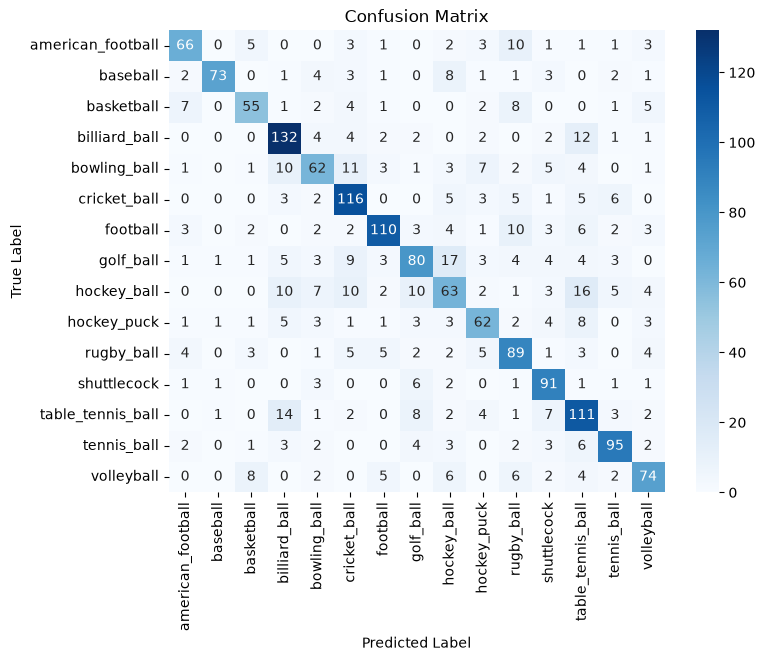

In [106]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### Precision, Recall and F1-score

In [110]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

                   precision    recall  f1-score   support

american_football       0.75      0.69      0.72        96
         baseball       0.95      0.73      0.82       100
       basketball       0.71      0.64      0.67        86
    billiard_ball       0.72      0.81      0.76       162
     bowling_ball       0.63      0.56      0.59       111
     cricket_ball       0.68      0.79      0.73       146
         football       0.82      0.73      0.77       151
        golf_ball       0.67      0.58      0.62       138
      hockey_ball       0.53      0.47      0.50       133
      hockey_puck       0.65      0.63      0.64        98
       rugby_ball       0.63      0.72      0.67       124
      shuttlecock       0.70      0.84      0.76       108
table_tennis_ball       0.61      0.71      0.66       156
      tennis_ball       0.78      0.77      0.78       123
       volleyball       0.71      0.68      0.69       109

         accuracy                           0.69      

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

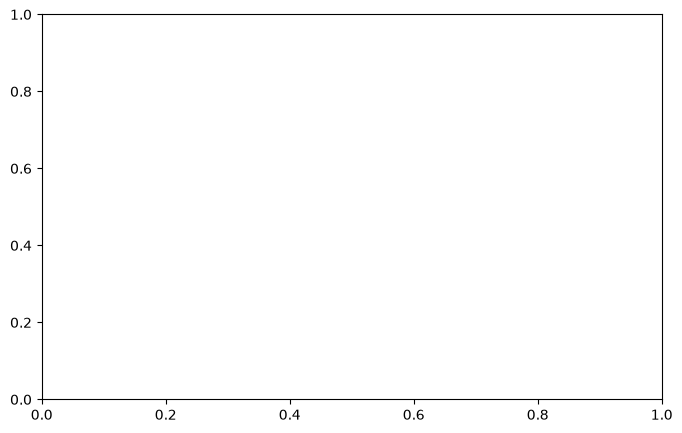

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, epoch_train_loss, label="Training Loss")
plt.plot(epochs, epoch_val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

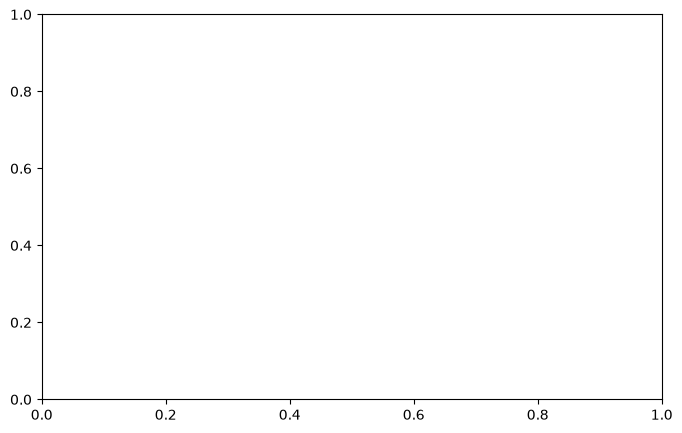

In [109]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracy, label="Training Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

### Find misclassified images

In [111]:
misclassified = []

for i in range(len(all_labels)):

    if all_labels[i] != all_predictions[i]:

        confidence = np.max(all_probabilities[i])

        misclassified.append({
            "index": i,
            "true": all_labels[i],
            "predicted": all_predictions[i],
            "confidence": confidence
        })

print("Number of misclassified images:", len(misclassified))

Number of misclassified images: 562


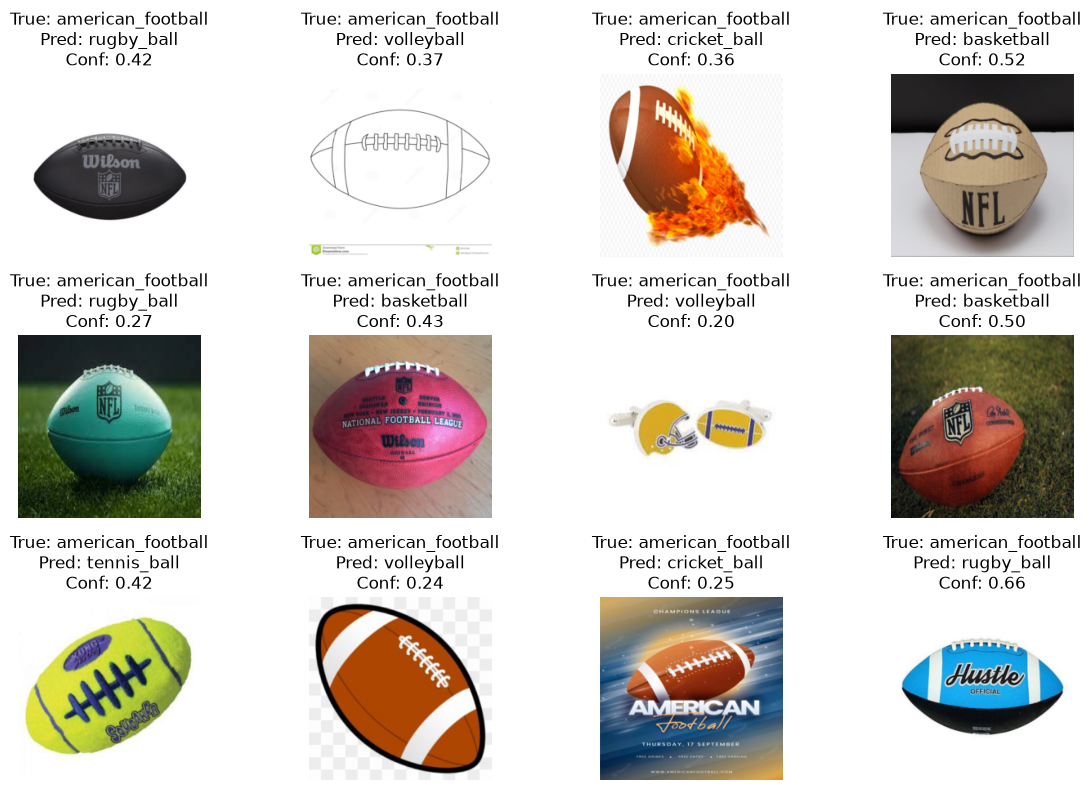

In [112]:
num_images = min(12, len(misclassified))

plt.figure(figsize=(12, 8))

mean = torch.tensor(imagenet_mean).view(3, 1, 1)
std = torch.tensor(imagenet_std).view(3, 1, 1)

for i in range(num_images):

    item = misclassified[i]

    index = item["index"]

    image = all_images[index]

    # Unnormalize
    image = image * std + mean
    image = image.clamp(0, 1)

    true_label = class_names[item["true"]]
    predicted_label = class_names[item["predicted"]]
    confidence = item["confidence"]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image.permute(1, 2, 0))

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Conf: {confidence:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

###  high-confidence and wrong predictions

In [113]:
high_confidence_errors = [
    item for item in misclassified
    if item["confidence"] >= 0.80
]

print(
    "High-confidence mistakes:",
    len(high_confidence_errors)
)

High-confidence mistakes: 7


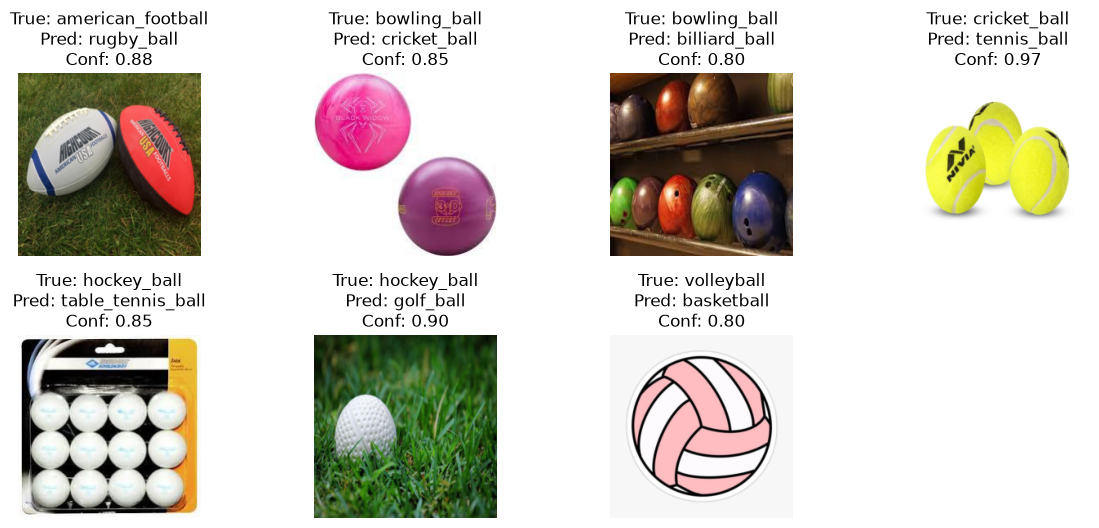

In [118]:
num_images = min(12, len(high_confidence_errors))

plt.figure(figsize=(12, 8))

for i in range(num_images):

    item = high_confidence_errors[i]

    index = item["index"]

    image = all_images[index]

    image = image * std + mean
    image = image.clamp(0, 1)

    true_label = class_names[item["true"]]
    predicted_label = class_names[item["predicted"]]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image.permute(1, 2, 0))

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Conf: {item['confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

The 4th image has wrong label. So we will find the path and remove it.

In [124]:
for item in high_confidence_errors:
    index = item["index"]

    path, label = test_dataset.samples[index]

    print("Path:", path)
    print("True:", class_names[item["true"]])
    print()

Path: Project_Dataset/test/american_football/american_football_692.jpg
True: american_football

Path: Project_Dataset/test/bowling_ball/bowling_ball_159.jpg
True: bowling_ball

Path: Project_Dataset/test/bowling_ball/bowling_ball_49.jpg
True: bowling_ball

Path: Project_Dataset/test/cricket_ball/cricket_ball_838.jpg
True: cricket_ball

Path: Project_Dataset/test/hockey_ball/hockey_ball_837.jpg
True: hockey_ball

Path: Project_Dataset/test/hockey_ball/hockey_ball_841.jpg
True: hockey_ball

Path: Project_Dataset/test/volleyball/volleyball_157.jpg
True: volleyball



In [ ]:
# Remove wrong lable image
os.remove("Project_Dataset/test/cricket_ball/cricket_ball_838.jpg")

In [120]:
for item in high_confidence_errors:
    index = item["index"]

    print("Index:", index)
    print("Path:", all_paths[index])
    print("True:", class_names[item["true"]])
    print("Predicted:", class_names[item["predicted"]])
    print("Confidence:", item["confidence"])
    print("-" * 80)

Index: 74


NameError: name 'all_paths' is not defined

### Calculate accuracy for each class

In [115]:
from sklearn.metrics import accuracy_score

for i, class_name in enumerate(class_names):

    mask = all_labels == i

    class_accuracy = accuracy_score(
        all_labels[mask],
        all_predictions[mask]
    )

    print(
        f"{class_name}: "
        f"{class_accuracy * 100:.2f}%"
    )

american_football: 68.75%
baseball: 73.00%
basketball: 63.95%
billiard_ball: 81.48%
bowling_ball: 55.86%
cricket_ball: 79.45%
football: 72.85%
golf_ball: 57.97%
hockey_ball: 47.37%
hockey_puck: 63.27%
rugby_ball: 71.77%
shuttlecock: 84.26%
table_tennis_ball: 71.15%
tennis_ball: 77.24%
volleyball: 67.89%
